In [1]:
import pandas as pd
import numpy as np

In [4]:
data= pd.read_csv(r"c:\Users\DeLL\OneDrive\Documents\Downloads\egypt_House_prices(Target column Price).csv")
data.head()

,Type,Price,Bedrooms,Bathrooms,Area,Furnished,Level,Compound,Payment_Option,Delivery_Date,Delivery_Term,City
0,Duplex,4000000,3,3,400,No,7,Unknown,Cash,Ready to move,Finished,Nasr City
1,Apartment,4000000,3,3,160,No,10+,Unknown,Cash,Ready to move,Finished,Camp Caesar
2,Apartment,2250000,3,2,165,No,1,Unknown,Cash,Ready to move,Finished,Smoha
3,Apartment,1900000,3,2,230,No,10,Unknown,Cash,Ready to move,Finished,Nasr City
4,Apartment,5800000,2,3,160,No,Ground,Eastown,Cash,Ready to move,Semi Finished,New Cairo - El Tagamoa


In [5]:
data.describe()

,Type,Price,Bedrooms,Bathrooms,Area,Furnished,Level,Compound,Payment_Option,Delivery_Date,Delivery_Term,City
count,27179,27302,26938,26988,26824,27267,27284,27219,27115,27258,27286,27334
unique,11,4180,12,12,785,3,14,559,4,10,5,183
top,Apartment,3000000,3,2,120,No,Unknown,Unknown,Cash or Installment,Ready to move,Finished,New Cairo - El Tagamoa
freq,8341,311,11677,9098,661,16447,10387,11013,10752,12094,14352,6771


In [6]:
data.shape

(27361, 12)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 27361 entries, 0 to 27360
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Type            27179 non-null  str  
 1   Price           27302 non-null  str  
 2   Bedrooms        26938 non-null  str  
 3   Bathrooms       26988 non-null  str  
 4   Area            26824 non-null  str  
 5   Furnished       27267 non-null  str  
 6   Level           27284 non-null  str  
 7   Compound        27219 non-null  str  
 8   Payment_Option  27115 non-null  str  
 9   Delivery_Date   27258 non-null  str  
 10  Delivery_Term   27286 non-null  str  
 11  City            27334 non-null  str  
dtypes: str(12)
memory usage: 2.5 MB


In [9]:
data.isnull().sum()

Type              182
Price              59
Bedrooms          423
Bathrooms         373
Area              537
Furnished          94
Level              77
Compound          142
Payment_Option    246
Delivery_Date     103
Delivery_Term      75
City               27
dtype: int64

In [10]:
data.shape

(27361, 12)

In [17]:
numeric_columns = ["Price", "Bedrooms", "Bathrooms", "Area"]

for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

In [12]:
data.isnull().sum()

Type              182
Price              96
Bedrooms          460
Bathrooms         410
Area              573
Furnished          94
Level              77
Compound          142
Payment_Option    246
Delivery_Date     103
Delivery_Term      75
City               27
dtype: int64

In [18]:
data = data.dropna(subset=["Price"])

In [19]:
numeric_columns = ["Price", "Bedrooms", "Bathrooms", "Area"]

for col in numeric_columns:
    data[col] = data[col].fillna(data[col].median())

In [20]:
categorical_columns = [
    "Type", "Furnished", "Level", "Compound",
    "Payment_Option", "Delivery_Date",
    "Delivery_Term", "City"
]

for col in categorical_columns:
    data[col] = data[col].fillna(data[col].mode()[0])

In [21]:
data.isnull().sum()

Type              0
Price             0
Bedrooms          0
Bathrooms         0
Area              0
Furnished         0
Level             0
Compound          0
Payment_Option    0
Delivery_Date     0
Delivery_Term     0
City              0
dtype: int64

In [22]:
data.duplicated().sum()

np.int64(1921)

In [23]:
data= data.drop_duplicates()

In [24]:
data.duplicated().sum()

np.int64(0)

In [25]:
data.describe()

,Price,Bedrooms,Bathrooms,Area
count,2.544000e+04,25440.000000,25440.000000,25440.000000
mean,4.834597e+06,3.256368,2.829324,229.960517
std,6.909532e+06,1.209622,1.355787,160.585209
min,3.000000e+04,1.000000,1.000000,10.000000
25%,1.150000e+06,3.000000,2.000000,125.000000
50%,2.772000e+06,3.000000,3.000000,175.000000
75%,6.000000e+06,4.000000,4.000000,272.000000
max,2.400000e+08,10.000000,10.000000,998.000000


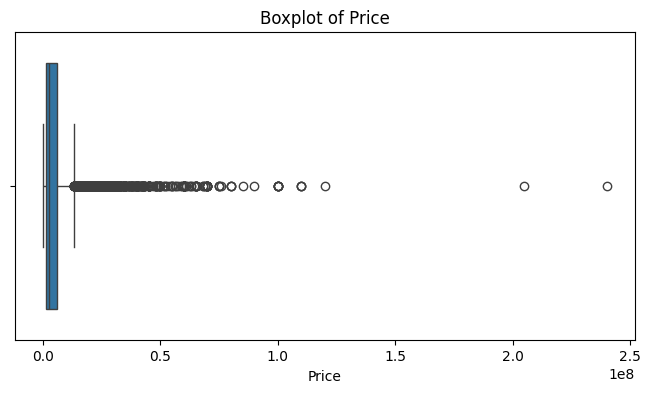

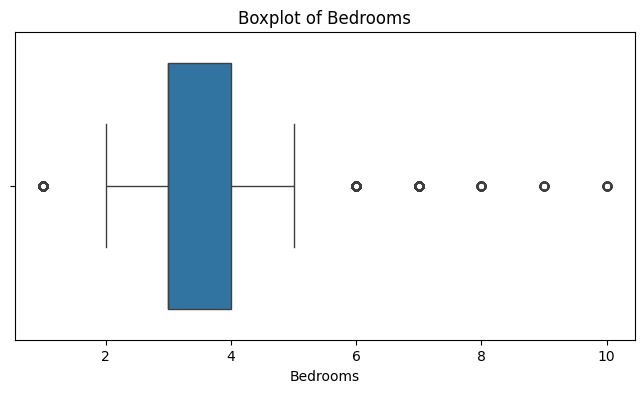

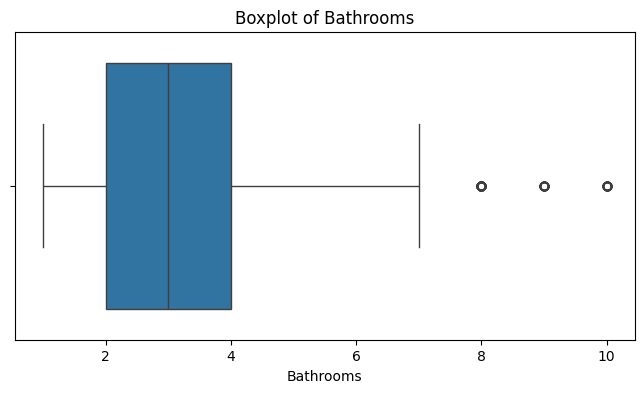

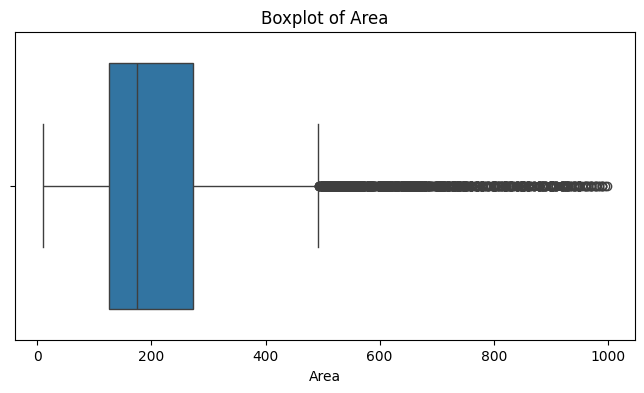

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_columns = ["Price", "Bedrooms", "Bathrooms", "Area"]

for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [28]:
numeric_columns = ["Price", "Bedrooms", "Bathrooms", "Area"]

for col in numeric_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]

    print(col, "outliers:", len(outliers))

Price outliers: 1894
Bedrooms outliers: 2072
Bathrooms outliers: 175
Area outliers: 2034


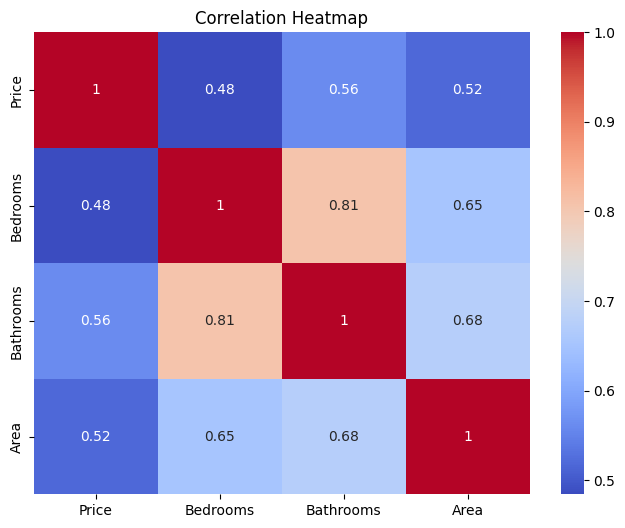

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_columns = ["Price", "Bedrooms", "Bathrooms", "Area"]

plt.figure(figsize=(8, 6))
sns.heatmap(data[numeric_columns].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

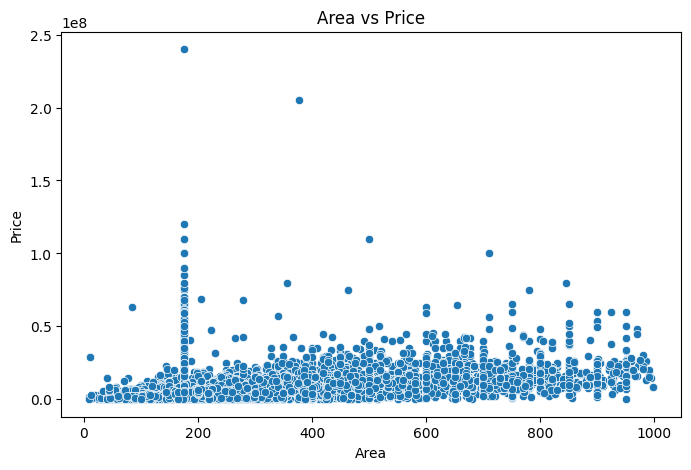

In [30]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=data["Area"], y=data["Price"])
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

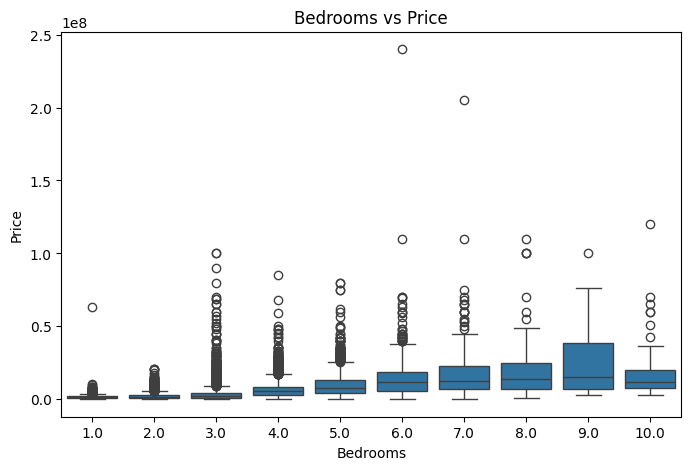

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=data["Bedrooms"], y=data["Price"])
plt.title("Bedrooms vs Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

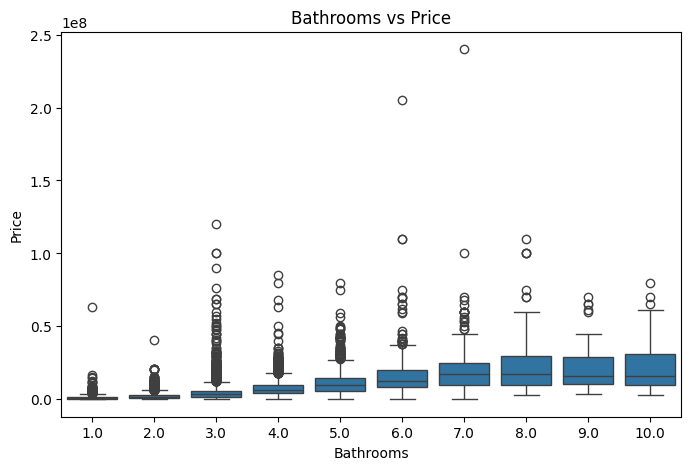

In [32]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=data["Bathrooms"], y=data["Price"])
plt.title("Bathrooms vs Price")
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.show()

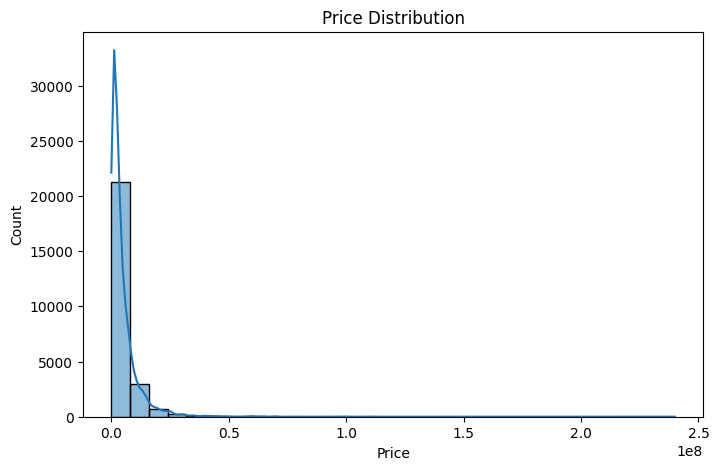

In [33]:
plt.figure(figsize=(8, 5))
sns.histplot(data["Price"], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

In [34]:
categorical_columns = [
    "Type",
    "Furnished",
    "Level",
    "Compound",
    "Payment_Option",
    "Delivery_Date",
    "Delivery_Term",
    "City"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(data[col].unique())


Type:
<StringArray>
[           'Duplex',         'Apartment',         'Penthouse',
            'Studio',           'Unknown',            'Chalet',
  'Standalone Villa',        'Twin house',        'Town House',
 'Stand Alone Villa',        'Twin House']
Length: 11, dtype: str

Furnished:
<StringArray>
['No', 'Unknown', 'Yes']
Length: 3, dtype: str

Level:
<StringArray>
[      '7',     '10+',       '1',      '10',  'Ground', 'Highest',       '3',
       '2',       '4',       '9',       '5',       '8',       '6', 'Unknown']
Length: 14, dtype: str

Compound:
<StringArray>
[              'Unknown',               'Eastown',         'Beit Al Watan',
                  'Jayd',            'Zayed 2000',             '90 Avenue',
               'Armonia',  'Palm Hills New Cairo',             'La Mirada',
               'Maadi V',
 ...
              'Paradise',               'Odyssia',              'Sun Rise',
      'Mirage Residence', 'The Waterway Compound',           'Royal Maxim',
      'Cleo

In [35]:
from sklearn.preprocessing import OneHotEncoder

categorical_columns = [
    "Type",
    "Furnished",
    "Level",
    "Compound",
    "Payment_Option",
    "Delivery_Date",
    "Delivery_Term",
    "City"
]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded_data = encoder.fit_transform(data[categorical_columns])

In [36]:
data["Type"] = data["Type"].replace({
    "Twin House": "Twin house",
    "Stand Alone Villa": "Standalone Villa"
})

In [37]:
data["Type"].unique()

<StringArray>
[          'Duplex',        'Apartment',        'Penthouse',
           'Studio',          'Unknown',           'Chalet',
 'Standalone Villa',       'Twin house',       'Town House']
Length: 9, dtype: str

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_columns = [
    "Type",
    "Furnished",
    "Level",
    "Compound",
    "Payment_Option",
    "Delivery_Date",
    "Delivery_Term",
    "City"
]

numeric_columns = [
    "Bedrooms",
    "Bathrooms",
    "Area"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("num", "passthrough", numeric_columns)
    ]
)

In [39]:
X = data.drop("Price", axis=1)
y = data["Price"]

In [40]:
print(X.shape)
print(y.shape)

(25440, 11)
(25440,)


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [42]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(20352, 11)
(5088, 11)
(20352,)
(5088,)


In [43]:
preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [44]:
X_train_encoded = preprocessor.transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [45]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(20352, 763)
(5088, 763)


In [46]:
print(type(X_train_encoded))

<class 'scipy.sparse._csr.csr_matrix'>


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [52]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(20352, 763)
(5088, 763)


In [48]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](763,)","[-529434.77,-316889.54,-255810.26,..., 434869.26,1414042.2 , 733294.85]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.735e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,763


In [49]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [50]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [51]:
n_neighbors=5
y_pred_knn = knn_model.predict(X_test_scaled)